---
## 0. Setup

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.figsize': (14, 4.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Physical constants — Nernst equation
R    = 8.314
F    = 96485.0
LN10 = np.log(10)

def nernst_slope(T_celsius):
    return -(R * (T_celsius + 273.15) * LN10 / F) * 1000

def nernst_correct(pH_meas, T_meas_C, T_cal_C=25.0, pH_iso=7.0):
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

T_CAL = 25.0
print(f'Nernst slope @ {T_CAL}°C : {nernst_slope(T_CAL):.3f} mV/pH')
print(f'Nernst slope @ 37°C    : {nernst_slope(37):.3f} mV/pH')

# ── Process metadata — Session 1 (28 April 2026) ──────────────────────────────
# Source: lab control sheet (fiche de fabrication)

T0_MOULAGE = pd.Timestamp('2026-04-28 11:36:00')  # true start of retournement

# Chauffage manual readings (clock times estimated from 0.3°C/min + moulage at 11:36)
manual_chauffage = pd.DataFrame({
    'datetime': pd.to_datetime([
        '2026-04-28 11:11', '2026-04-28 11:16', '2026-04-28 11:21',
        '2026-04-28 11:26', '2026-04-28 11:31', '2026-04-28 11:36',
    ]),
    'T_C': [35.0, 36.4, 38.0, 39.6, 40.2, 40.2],
    'pH':  [6.63, 6.61, 6.60, 6.58, 6.53, 6.57],
}).set_index('datetime')

# Retournement manual readings (exact clock times from fiche)
manual_retournement = pd.DataFrame({
    'datetime': pd.to_datetime([
        '2026-04-28 11:41', '2026-04-28 12:06', '2026-04-28 13:10',
        '2026-04-28 14:18', '2026-04-28 14:41',
    ]),
    't_min': [5,    30,   94,   162,  185],
    'T_C':   [38.3, 38.1, 36.1, 34.5, 33.8],
    'pH':    [6.10, 5.90, 5.40, 5.22, 5.15],
}).set_index('datetime')

print(f'\nMoulage (true t=0): {T0_MOULAGE}')
print(f'Manual retournement: {len(manual_retournement)} points — '
      f'{manual_retournement.index[0].strftime("%H:%M")} → '
      f'{manual_retournement.index[-1].strftime("%H:%M")}')

Nernst slope @ 25.0°C : -59.156 mV/pH
Nernst slope @ 37°C    : -61.537 mV/pH

Moulage (true t=0): 2026-04-28 11:36:00
Manual retournement: 5 points — 11:41 → 14:41


---
## 0.1 Process Metadata — Session 1 (28 April 2026)
*Source: fiche de fabrication (lab control sheet)*

### Milk & cultures
| Parameter | Value |
|---|---|
| Milk quantity | 282 kg |
| Milk temperature (8h18) | 8.6 °C |
| Milk pH (morning) | **6.28** |
| Culture 1 — MFR 38°C (type 280) | **974.2 g** |
| Culture 2 — MFR 32°C (type 901) | **282 g** |
| Ratio MFR38 / MFR32 | **3.45 : 1** |
| Rennet (Winkler GR orange, 1:9000) | 55 ml |

### Coagulation & fabrication
| Step | Value |
|---|---|
| Coagulation T° | 31.4 °C |
| Prise (coagulation time) | 18 min 32 s |
| Durcissement | 29 min 10 s |
| Heating rate | 0.3 °C / min |
| Brassage final T° / pH | 40.2 °C / 6.50 |
| **Moulage (true t = 0)** | **11:36** |

### Manual pH/T° — Retournement
| Clock | t (min) | pH | T°C |
|---|---|---|---|
| 11:41 | 5 | 6.10 | 38.3 |
| 12:06 | 30 | 5.90 | 38.1 |
| 13:10 | 94 | 5.40 | 36.1 |
| 14:18 | 162 | 5.22 | 34.5 |
| 14:41 | 185 | **5.15** | 33.8 |

### Yield
| | Value |
|---|---|
| Number of pieces | 6 |
| Total cheese mass | **34.34 kg** |
| Mass per piece | 5.7 kg |
| **Fresh yield** | **12.17 %** |
| Unmolding note | "already reached pH 5.2" |
| Microbiology | < 10² ufc/ml enterococcus · 20 000 ufc/ml total |

---
## 1. Chargement & Inspection des Données Brutes

In [2]:
# ── Fromage 1 — USB (pH + mV, 1 min) ─────────────────────────────────────────
df1_raw = pd.read_csv(
    'data/trace pH fromage 1_USB_28042026.csv',
    usecols=['Date', 'Time', 'Ch1_M1', 'Ch1_M3'],
)
df1_raw['datetime'] = pd.to_datetime(
    df1_raw['Date'] + ' ' + df1_raw['Time'], format='%d/%b/%Y %H:%M:%S'
)
df1_raw['pH'] = pd.to_numeric(df1_raw['Ch1_M1'], errors='coerce')
df1_raw['mV'] = pd.to_numeric(df1_raw['Ch1_M3'], errors='coerce')
df1_all = df1_raw[['datetime', 'pH', 'mV']].dropna().set_index('datetime').sort_index()

# Filter 1: 28 April only (USB recorded 2+ days)
df1_all = df1_all[df1_all.index.date == pd.Timestamp('2026-04-28').date()]
# Filter 2: physical bounds (probe outside milk or calibration)
df1_all = df1_all[(df1_all['pH'] >= 3.5) & (df1_all['pH'] <= 7.0)].copy()
# Filter 3: analysis window 11h–16h (moulage at 11:36, démoulage ~14:41)
df1_all = df1_all[
    (df1_all.index >= pd.Timestamp('2026-04-28 11:00:00')) &
    (df1_all.index <= pd.Timestamp('2026-04-28 16:00:00'))
].copy()
# Filter 4: rolling-median outlier removal
#   Cross-check vs fiche: USB shows pH 4.02 at 14:18 while manual reads 5.22 → isolated spike
#   Remove any point deviating > 0.40 pH from its 15-min rolling median
rolling_med = df1_all['pH'].rolling(window=15, center=True, min_periods=3).median()
n_before = len(df1_all)
df1 = df1_all[np.abs(df1_all['pH'] - rolling_med) < 0.40].copy()
n_removed = n_before - len(df1)

print(f'Fromage 1 (USB)    : {len(df1):,} points | {df1.index[0]} → {df1.index[-1]}')
print(f'  Filter 4 (rolling median): {n_removed} spike(s) removed '
      f'(e.g. pH 4.02 at 14:18 — confirmed artefact vs. manual pH 5.22)')
df1.describe()

Fromage 1 (USB)    : 271 points | 2026-04-28 11:00:37 → 2026-04-28 15:59:37
  Filter 4 (rolling median): 7 spike(s) removed (e.g. pH 4.02 at 14:18 — confirmed artefact vs. manual pH 5.22)


,pH,mV
count,271.000000,271.000000
mean,5.403100,94.649446
std,0.440015,25.832344
min,3.990000,51.000000
25%,5.280000,79.500000
50%,5.430000,93.000000
75%,5.660000,102.000000
max,6.150000,177.000000


In [3]:
# ── Fromage 2 — Server (pH uniquement, ~1 s → rééchantillonné 1 min) ──────────
df2_raw = pd.read_csv(
    'data/trace pH fromage 2_Server_28042026.csv',
    names=['datetime', 'pH'], skiprows=1,
)
df2_raw['datetime'] = pd.to_datetime(df2_raw['datetime'])
df2_raw['pH'] = pd.to_numeric(df2_raw['pH'], errors='coerce')
df2_raw = df2_raw.dropna().set_index('datetime').sort_index()
# Supprimer les artefacts
df2_clean = df2_raw[(df2_raw['pH'] >= 3.5) & (df2_raw['pH'] <= 7.0)].copy()
# Supprimer la période 10h–11h30 (sonde hors mesure réelle)
df2_clean = df2_clean[df2_clean.index >= pd.Timestamp('2026-04-28 11:30:00')]
# Rééchantillonnage à 1 min (médiane) — résolution commune avec USB et Hannah
df2 = df2_clean['pH'].resample('1min').median().dropna().to_frame()

print(f'Fromage 2 (Server) : {len(df2_raw):,} pts bruts | artefacts éliminés : {len(df2_raw) - len(df2_clean):,}')
print(f'  Après filtre 10h–11h30 + rééchantillonnage 1 min : {len(df2):,} points | {df2.index[0]} → {df2.index[-1]}')
df2.describe()

Fromage 2 (Server) : 7,469 pts bruts | artefacts éliminés : 1,211
  Après filtre 10h–11h30 + rééchantillonnage 1 min : 228 points | 2026-04-28 11:30:00 → 2026-04-28 15:37:00


,pH
count,228.000000
mean,4.994551
std,0.292629
min,4.547967
25%,4.773104
50%,4.897978
75%,5.167208
max,6.222823


In [4]:
# ── Fromage 3 — Hannah (pH + mV + T°C, 1 min) ────────────────────────────────
# skiprows=20 : ignore les 19 lignes de métadonnées + la ligne header CSV
df3_raw = pd.read_csv(
    'data/trace pH fromage 3_28042026_hannah.csv',
    skiprows=20, header=None,
    names=['_', 'rec', 'date', 'time', 'pH', 'u1', 'mV', 'u2', 'temp_C', 'u3', '_2'],
    usecols=['date', 'time', 'pH', 'mV', 'temp_C'],
    encoding='latin-1',
)
df3_raw['datetime'] = pd.to_datetime(
    df3_raw['date'].str.strip() + ' ' + df3_raw['time'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)
for col in ['pH', 'mV', 'temp_C']:
    df3_raw[col] = pd.to_numeric(df3_raw[col], errors='coerce')
df3_all = df3_raw[['datetime', 'pH', 'mV', 'temp_C']].dropna().set_index('datetime').sort_index()
# Supprimer les artefacts
df3 = df3_all[(df3_all['pH'] >= 3.5) & (df3_all['pH'] <= 7.0)].copy()

print(f'Fromage 3 (Hannah) : {len(df3):,} points | {df3.index[0]} → {df3.index[-1]}')
print(f'  Artefacts éliminés : {len(df3_all) - len(df3):,} points (pH < 3.5 ou > 7.0)')
df3.describe()

Fromage 3 (Hannah) : 251 points | 2026-04-28 12:08:53 → 2026-04-28 16:18:54
  Artefacts éliminés : 0 points (pH < 3.5 ou > 7.0)


,pH,mV,temp_C
count,251.000000,251.000000,251.000000
mean,5.301992,104.320319,31.166534
std,0.273687,14.732121,6.026023
min,5.020000,59.600000,23.100000
25%,5.040000,96.600000,23.700000
50%,5.240000,109.200000,34.600000
75%,5.465000,117.000000,36.200000
max,6.040000,118.700000,39.300000


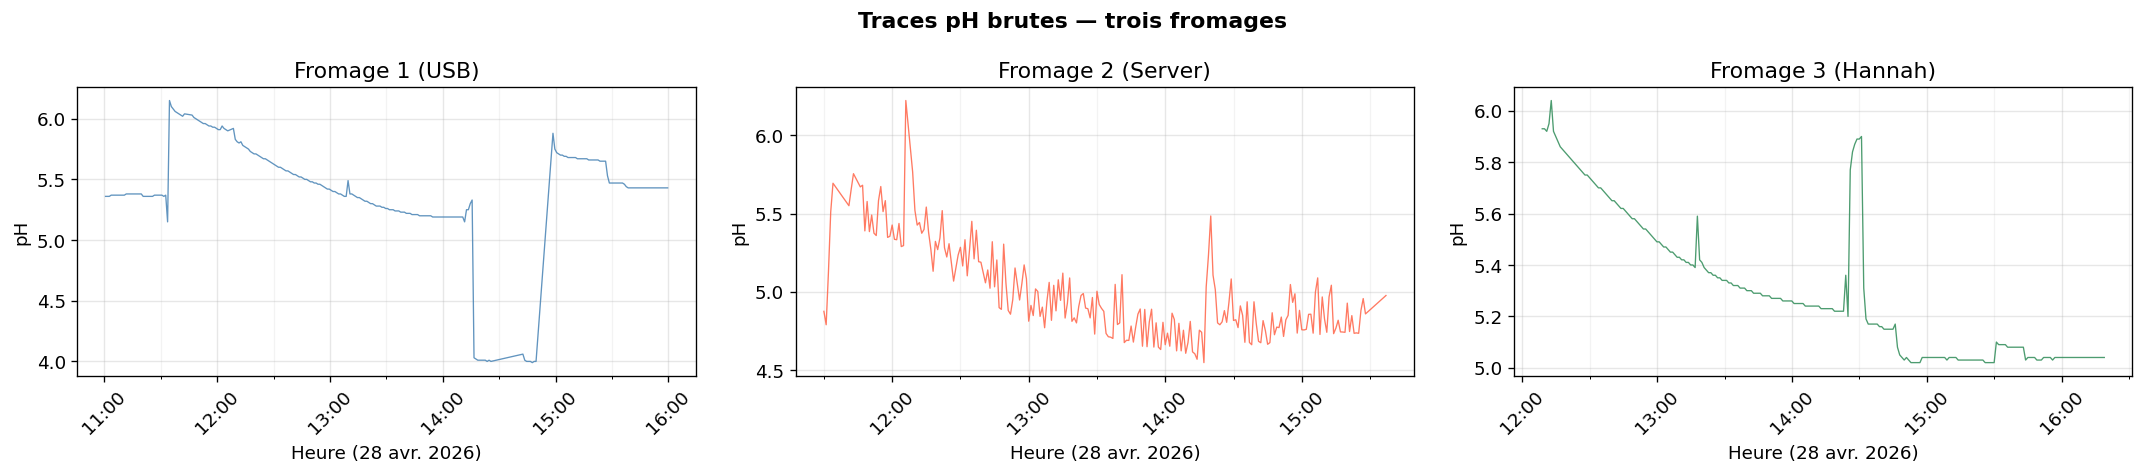

In [5]:
# Vue d'ensemble brute — 3 panneaux
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, df, label, color in zip(
    axes,
    [df1, df2, df3],
    ['Fromage 1 (USB)', 'Fromage 2 (Server)', 'Fromage 3 (Hannah)'],
    ['steelblue', 'tomato', 'seagreen'],
):
    duration_h = (df.index[-1] - df.index[0]).total_seconds() / 3600
    major_interval = 2 if duration_h > 8 else 1

    ax.plot(df.index, df['pH'], color=color, linewidth=0.8, alpha=0.85)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (28 avr. 2026)')

plt.suptitle('Traces pH brutes — trois fromages', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_raw_traces.png', bbox_inches='tight')
plt.show()

---
## 2. Interpolation — Combler les Lacunes du Signal Server (Fromage 2)

Le logger server a été rééchantillonné à **1 minute** dès le chargement (médiane par fenêtre de 60 s).  
Certaines minutes restent manquantes lorsque le logger n'a enregistré aucune donnée pendant plus de **2 minutes** consécutives.  
On construit une grille temporelle régulière à **1 minute** et on comble ces lacunes par **interpolation linéaire**.  
Les segments dont la lacune dépasse **120 s** sont marqués comme non fiables.

In [6]:
# ── Détection des lacunes ─────────────────────────────────────────────────────
GAP_THRESHOLD_S = 120   # > 2 min = lacune réelle sur grille 1 min
dt_seconds = df2.index.to_series().diff().dt.total_seconds()
gaps = dt_seconds[dt_seconds > GAP_THRESHOLD_S].dropna()
print(f'Lacunes > {GAP_THRESHOLD_S} s dans Fromage 2 : {len(gaps)}')
if len(gaps):
    print(gaps.apply(lambda s: f'{s:.0f} s').to_frame('durée_lacune'))

# ── Grille régulière 1 min ────────────────────────────────────────────────────
t_start     = df2.index[0]
t_end       = df2.index[-1]
regular_idx = pd.date_range(t_start, t_end, freq='1min')

t_orig = (df2.index - t_start).total_seconds().values
t_new  = (regular_idx - t_start).total_seconds().values

interp_fn = interp1d(t_orig, df2['pH'].values, kind='linear',
                     bounds_error=False, fill_value=np.nan)
pH_interp = interp_fn(t_new)

# ── Masquer les segments interpolés dans les grandes lacunes ──────────────────
reliable = np.ones(len(regular_idx), dtype=bool)
for gap_ts, gap_dur in gaps.items():
    prev_ts = gap_ts - pd.Timedelta(seconds=gap_dur)
    mask = (regular_idx > prev_ts) & (regular_idx < gap_ts)
    reliable[mask] = False

df2_interp = pd.DataFrame({'pH': pH_interp, 'reliable': reliable}, index=regular_idx)
print(f'\nGrille régulière : {len(df2_interp):,} pts | fiables : {reliable.sum():,}')

Lacunes > 120 s dans Fromage 2 : 4
                    durée_lacune
datetime                        
2026-04-28 11:41:00        420 s
2026-04-28 11:46:00        180 s
2026-04-28 12:09:00        180 s
2026-04-28 15:37:00        540 s

Grille régulière : 248 pts | fiables : 230


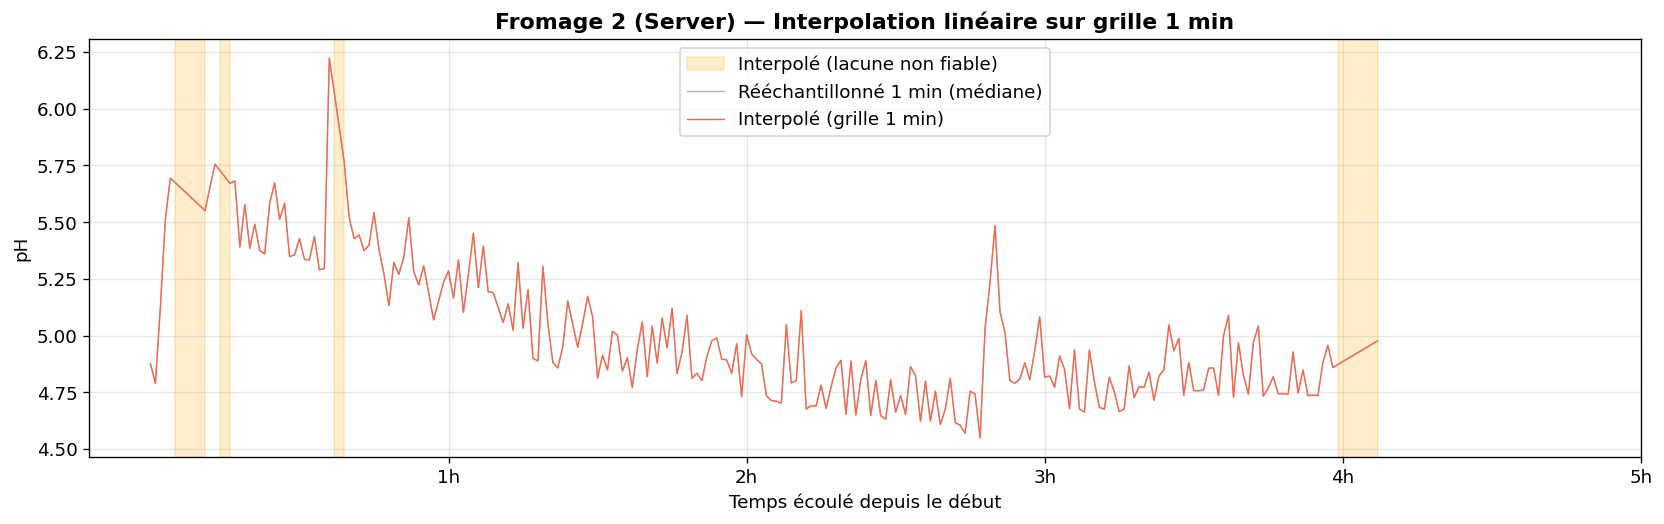

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.5))

t0 = df2_interp.index[0]

def to_hours(idx):
    return (idx - t0).total_seconds() / 3600

# Zones d'interpolation non fiables
in_gap, gap_start = False, None
for ts, row in df2_interp.iterrows():
    if not row['reliable'] and not in_gap:
        gap_start, in_gap = ts, True
    elif row['reliable'] and in_gap:
        ax.axvspan(to_hours(gap_start), to_hours(ts), alpha=0.2, color='orange',
                   label='Interpolé (lacune non fiable)')
        in_gap = False
if in_gap:
    ax.axvspan(to_hours(gap_start), to_hours(df2_interp.index[-1]), alpha=0.2, color='orange')

ax.plot(to_hours(df2.index), df2['pH'],
        color='grey', linewidth=0.8, alpha=0.6, label='Rééchantillonné 1 min (médiane)')
ax.plot(to_hours(df2_interp.index), df2_interp['pH'],
        color='tomato', linewidth=0.8, label='Interpolé (grille 1 min)')

x_max = to_hours(df2_interp.index[-1])
ticks = np.arange(1, int(np.ceil(x_max)) + 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{int(t)}h' for t in ticks])

ax.set_title('Fromage 2 (Server) — Interpolation linéaire sur grille 1 min', fontweight='bold')
ax.set_xlabel('Temps écoulé depuis le début')
ax.set_ylabel('pH')
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_interpolation.png', bbox_inches='tight')
plt.show()

---
## 3. Rééchantillonnage

Les trois signaux sont rééchantillonnés à la **médiane sur 1 minute** pour aligner les horodatages.  
Le signal Server (~1 s) présente un bruit résiduel important non supprimé par la seule médiane 1 min.  
Un **filtre de Savitzky-Golay** (fenêtre 21 min, degré 3) est appliqué uniquement au Server pour lisser sans déformer la tendance ni introduire de décalage temporel.

In [8]:
RESAMPLE_FREQ = '1min'
SG_WINDOW     = 21   # Savitzky-Golay window for Server (minutes, must be odd)

def resample_data(series, freq=RESAMPLE_FREQ):
    return series.resample(freq).median().dropna()

df1_res = df1_smooth = resample_data(df1['pH'])
df3_res = df3_smooth = resample_data(df3['pH'])

# Server (Fromage 2) : médiane 1 min puis Savitzky-Golay
# Le signal brut ~1 s présente des oscillations de ±0.2 pH qui subsistent après
# la médiane 1 min. SG filtre ces oscillations haute fréquence tout en préservant
# la forme de la courbe (pas de décalage temporel contrairement à un rolling mean).
df2_res  = resample_data(df2_interp['pH'])
_sg_vals = savgol_filter(df2_res.values, window_length=SG_WINDOW, polyorder=3)
df2_smooth = pd.Series(_sg_vals, index=df2_res.index, name='pH')

df1_mV_res   = df1['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_mV_res   = df3['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_temp_res = df3['temp_C'].resample(RESAMPLE_FREQ).median().dropna()

print('Tailles après rééchantillonnage :')
for name, s in [('Fromage 1 (USB)',      df1_res),
                ('Fromage 2 (Server brut)', df2_res),
                ('Fromage 2 (Server SG)',   df2_smooth),
                ('Fromage 3 (Hannah)',    df3_res)]:
    print(f'  {name} : {len(s):,} points')
print(f'\nServer : Savitzky-Golay fenêtre={SG_WINDOW} min, degré=3')

Tailles après rééchantillonnage :
  Fromage 1 (USB) : 271 points
  Fromage 2 (Server brut) : 248 points
  Fromage 2 (Server SG) : 248 points
  Fromage 3 (Hannah) : 251 points

Server : Savitzky-Golay fenêtre=21 min, degré=3


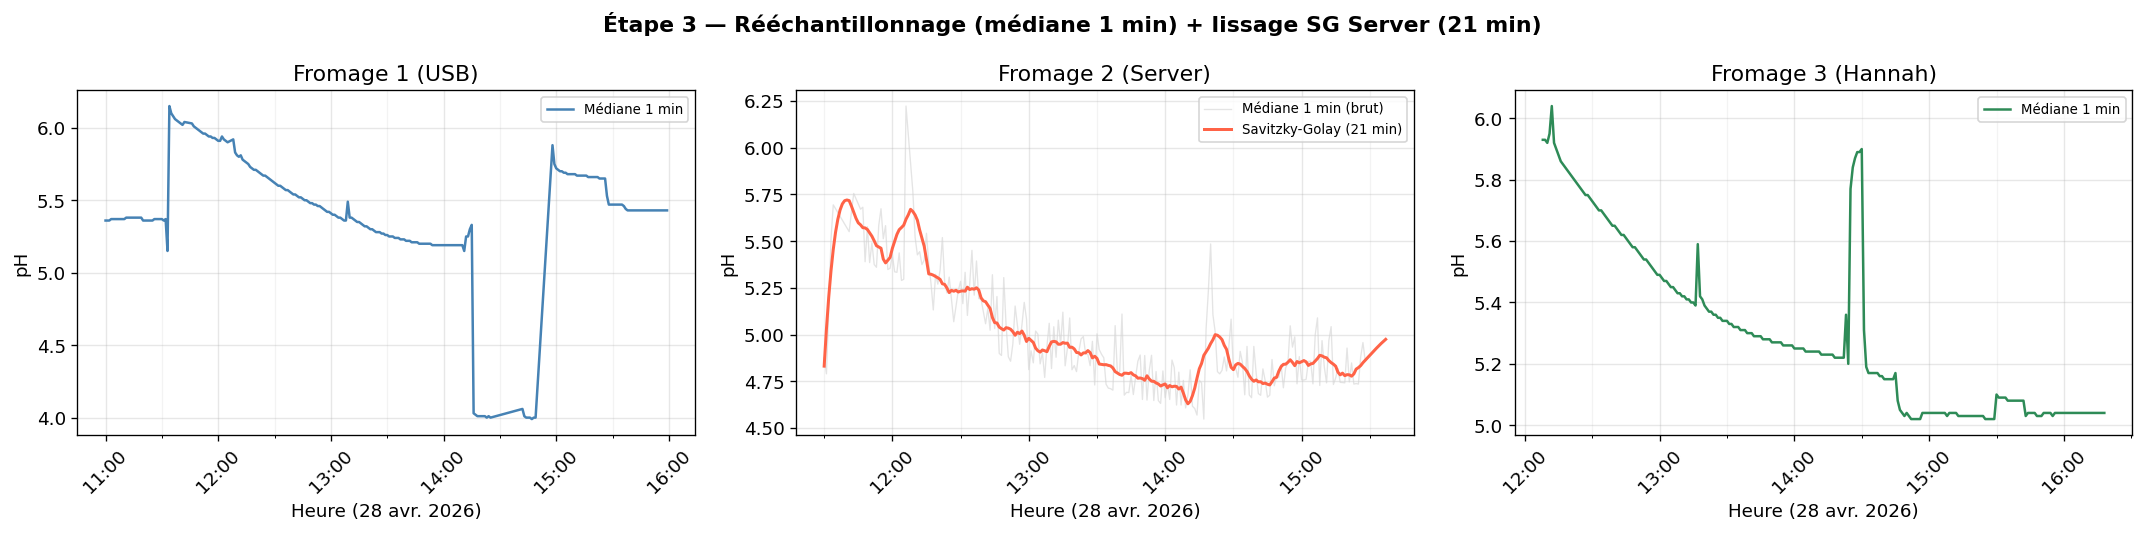

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

datasets = [
    (df1_res, None,       'Fromage 1 (USB)',    'steelblue'),
    (df2_res, df2_smooth, 'Fromage 2 (Server)', 'tomato'),
    (df3_res, None,       'Fromage 3 (Hannah)', 'seagreen'),
]

for ax, (res, smoothed, label, color) in zip(axes, datasets):
    if smoothed is not None:
        ax.plot(res.index, res.values, color='lightgrey', linewidth=0.8, alpha=0.6,
                label='Médiane 1 min (brut)')
        ax.plot(smoothed.index, smoothed.values, color=color, linewidth=1.8,
                label=f'Savitzky-Golay ({SG_WINDOW} min)')
    else:
        ax.plot(res.index, res.values, color=color, linewidth=1.5, label='Médiane 1 min')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (28 avr. 2026)')
    ax.legend(fontsize=8)

plt.suptitle(f'Étape 3 — Rééchantillonnage (médiane 1 min) + lissage SG Server ({SG_WINDOW} min)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_resampling.png', bbox_inches='tight')
plt.show()

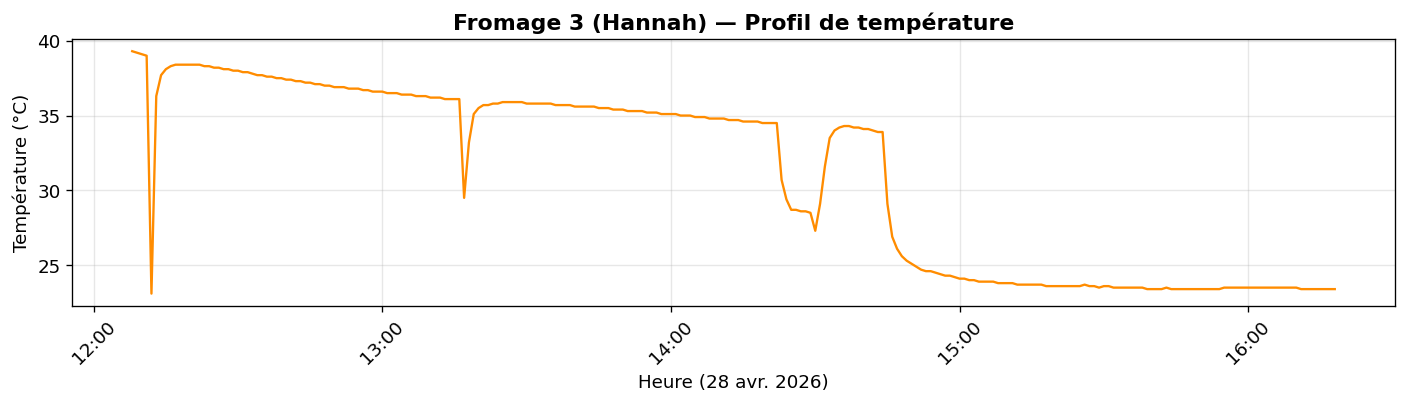

In [10]:
# Profil de température — Fromage 3
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df3_temp_res.index, df3_temp_res.values, color='darkorange', linewidth=1.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_title('Fromage 3 (Hannah) — Profil de température', fontweight='bold')
ax.set_ylabel('Température (°C)')
ax.set_xlabel('Heure (28 avr. 2026)')
plt.tight_layout()
plt.show()

---
## 4. Correction de Nernst — Correction du pH par la Température

Une électrode pH suit l'**équation de Nernst** :

$$E = E_0 - \frac{RT\ln 10}{F}\cdot\mathrm{pH}$$

La pente $S(T) = -\frac{RT\ln 10}{F}$ dépend de la température
(-59,16 mV/pH à 25 °C, -61,54 mV/pH à 37 °C).  
Lorsque la calibration se fait à $T_{\text{cal}}$ mais la mesure à $T_{\text{mes}}$,
le pH affiché est décalé. La valeur corrigée est :

$$\mathrm{pH}_{\text{corr}} =
  \mathrm{pH}_{\text{iso}} +
  (\mathrm{pH}_{\text{mes}} - \mathrm{pH}_{\text{iso}})
  \cdot \frac{T_{\text{mes}}}{T_{\text{cal}}}$$

où $T$ est en **Kelvin** et $\mathrm{pH}_{\text{iso}} \approx 7{,}0$ (point isoélectrique).

| Source | T disponible ? | mV disponible ? | Correction |
|--------|----------------|-----------------|------------|
| Fromage 1 (USB)    | ✗ supposée 35 °C | ✓ | Rapport de pente |
| Fromage 2 (Server) | ✗ supposée 35 °C | ✗ | Rapport de pente |
| Fromage 3 (Hannah) | ✓ mesurée        | ✓ | Correction complète |

In [11]:
PH_ISO  = 7.0

def nernst_correct(pH_meas, T_meas_C, T_cal_C=T_CAL, pH_iso=PH_ISO):
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

# ── Fromage 1 : température supposée 35 °C ────────────────────────────────────
T_F1_ASSUMED = 35.0
pH1_corr = nernst_correct(df1_smooth, T_meas_C=T_F1_ASSUMED)

# ── Fromage 2 : température supposée 35 °C ────────────────────────────────────
T_F2_ASSUMED = 35.0
pH2_corr = nernst_correct(df2_smooth, T_meas_C=T_F2_ASSUMED)

# ── Fromage 3 (Hannah) : pas de correction Nernst ─────────────────────────────
# La sonde Hanna HI11312 effectue déjà une compensation automatique de
# température (ATC) en interne via son capteur de température intégré.
# Appliquer une deuxième correction Nernst introduirait une double compensation.
idx3     = df3_smooth.index.intersection(df3_temp_res.index)
pH3_meas = df3_smooth.loc[idx3]
temp3    = df3_temp_res.loc[idx3]
pH3_corr = pH3_meas.copy()   # ATC interne — pas de correction supplémentaire

# Résumé
print("Correction Nernst appliquée à F1 et F2 (T supposée 35°C)")
print("F3 (Hannah) : ATC interne — valeur brute utilisée directement")
print(f"Δ pH moyen F1 : {(pH1_corr - df1_smooth).mean():.4f}")
print(f"Δ pH moyen F2 : {(pH2_corr - df2_smooth).mean():.4f}")


Correction Nernst appliquée à F1 et F2 (T supposée 35°C)
F3 (Hannah) : ATC interne — valeur brute utilisée directement
Δ pH moyen F1 : -0.0536
Δ pH moyen F2 : -0.0663


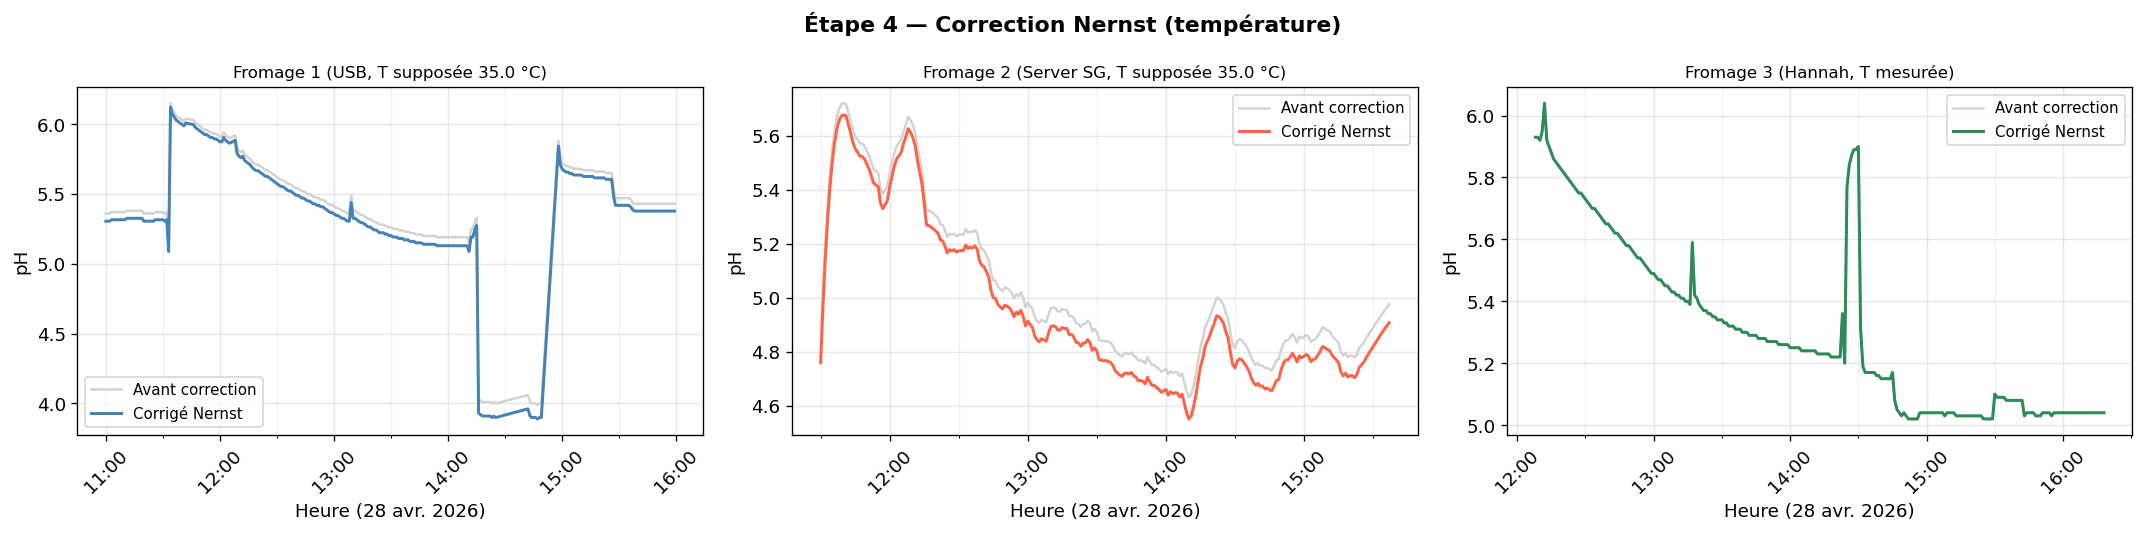

In [12]:
# ── Avant / après correction pour chaque fromage ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Server : déjà lissé par SG en étape 3 — pas de rolling supplémentaire nécessaire
spec = [
    (df1_smooth, pH1_corr, f'Fromage 1 (USB, T supposée {T_F1_ASSUMED} °C)', 'steelblue'),
    (df2_smooth, pH2_corr, f'Fromage 2 (Server SG, T supposée {T_F2_ASSUMED} °C)', 'tomato'),
    (pH3_meas,   pH3_corr,  'Fromage 3 (Hannah, T mesurée)', 'seagreen'),
]

for ax, (measured, corrected, label, color) in zip(axes, spec):
    ax.plot(measured.index,  measured.values,  color='lightgrey', linewidth=1.5,
            label='Avant correction')
    ax.plot(corrected.index, corrected.values, color=color, linewidth=1.8,
            label='Corrigé Nernst')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (28 avr. 2026)')
    ax.legend(fontsize=9)

plt.suptitle('Étape 4 — Correction Nernst (température)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_nernst_correction.png', bbox_inches='tight')
plt.show()

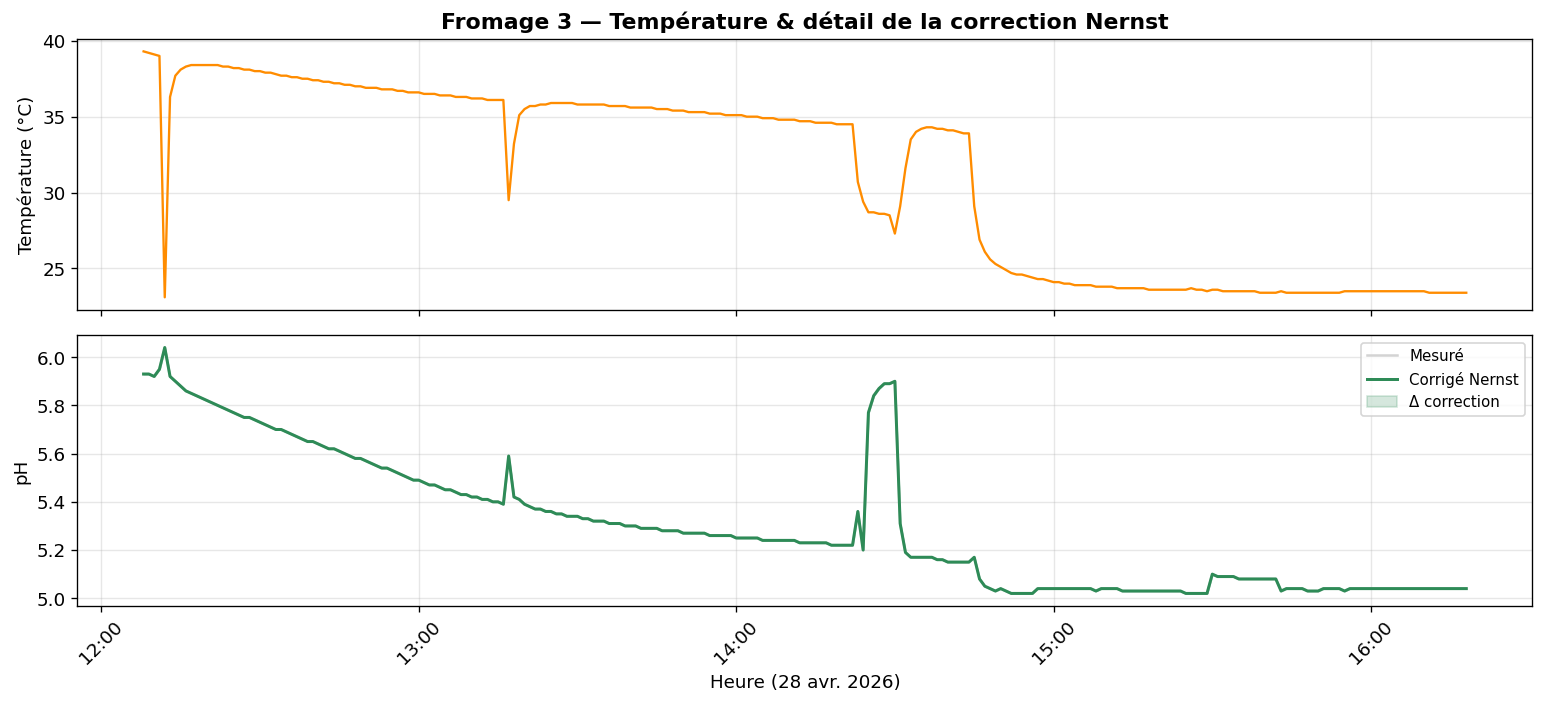

In [13]:
# ── Fromage 3 : détail correction vs. fluctuations de température ─────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(temp3.index, temp3.values, color='darkorange', linewidth=1.4)
axes[0].set_ylabel('Température (°C)')
axes[0].set_title('Fromage 3 — Température & détail de la correction Nernst',
                  fontweight='bold')

axes[1].plot(pH3_meas.index, pH3_meas.values, color='lightgrey', linewidth=1.5,
             label='Mesuré')
axes[1].plot(pH3_corr.index, pH3_corr.values, color='seagreen', linewidth=1.8,
             label='Corrigé Nernst')
axes[1].fill_between(pH3_meas.index, pH3_meas.values, pH3_corr.values,
                     alpha=0.2, color='seagreen', label='Δ correction')
axes[1].set_ylabel('pH')
axes[1].set_xlabel('Heure (28 avr. 2026)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04b_nernst_fromage3_detail.png', bbox_inches='tight')
plt.show()

---
## 5. Comparaison Finale — Profils Corrigés (alignés depuis t = 0)

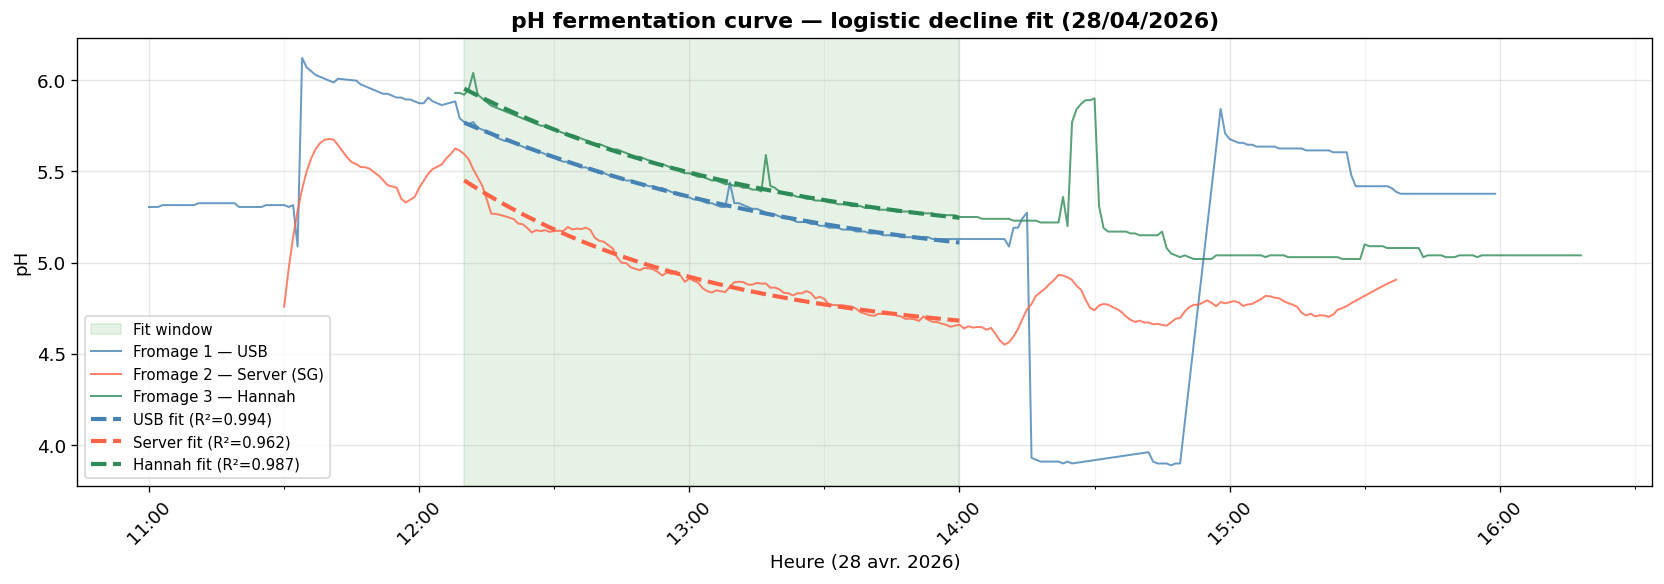

In [14]:
def logistic_decline(t, L, pH0, k, t0):
    """pH(t) = L + (pH0 - L) / (1 + exp(k*(t - t0)))"""
    return L + (pH0 - L) / (1 + np.exp(k * (t - t0)))

def fit_logistic(series, fit_start, fit_end):
    t_abs = series.index
    t = (t_abs - t_abs[0]).total_seconds() / 3600
    y = series.values
    mask = (t_abs >= fit_start) & (t_abs <= fit_end)
    t_fit, y_fit = t[mask], y[mask]
    p0 = [y.min(), y.max(), 2.0, np.median(t_fit)]
    try:
        popt, _ = curve_fit(logistic_decline, t_fit, y_fit, p0=p0, maxfev=10000)
        y_pred_fit = logistic_decline(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred_fit) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        return t_abs[mask], y_pred_fit, r2
    except Exception as e:
        print(f'Fit échoué : {e}')
        return None, None, None

# Server déjà lissé par SG — pas de rolling supplémentaire
pH2_corr_vis = pH2_corr.dropna()

FW_START = pd.Timestamp('2026-04-28 12:10')
FW_END   = pd.Timestamp('2026-04-28 14:00')

idx1, fit1, r2_1 = fit_logistic(pH1_corr,     FW_START, FW_END)
idx2, fit2, r2_2 = fit_logistic(pH2_corr_vis, FW_START, FW_END)
idx3, fit3, r2_3 = fit_logistic(pH3_corr,     FW_START, FW_END)

fig, ax = plt.subplots(figsize=(14, 5))

ax.axvspan(FW_START, FW_END, alpha=0.10, color='green', label='Fit window')

ax.plot(pH1_corr.index,     pH1_corr.values,     color='steelblue', linewidth=1.2, alpha=0.8,
        label='Fromage 1 — USB')
ax.plot(pH2_corr_vis.index, pH2_corr_vis.values, color='tomato',    linewidth=1.2, alpha=0.8,
        label='Fromage 2 — Server (SG)')
ax.plot(pH3_corr.index,     pH3_corr.values,     color='seagreen',  linewidth=1.2, alpha=0.8,
        label='Fromage 3 — Hannah')

if fit1 is not None:
    ax.plot(idx1, fit1, color='steelblue', linewidth=2.5, linestyle='--',
            label=f'USB fit (R²={r2_1:.3f})')
if fit2 is not None:
    ax.plot(idx2, fit2, color='tomato',    linewidth=2.5, linestyle='--',
            label=f'Server fit (R²={r2_2:.3f})')
if fit3 is not None:
    ax.plot(idx3, fit3, color='seagreen',  linewidth=2.5, linestyle='--',
            label=f'Hannah fit (R²={r2_3:.3f})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
ax.grid(True, which='minor', alpha=0.15)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Heure (28 avr. 2026)')
ax.set_ylabel('pH')
ax.set_title('pH fermentation curve — logistic decline fit (28/04/2026)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_final_comparison.png', bbox_inches='tight')
plt.show()

In [15]:
# ── Table des jalons clés ──────────────────────────────────────────────────────
def first_crossing(series, threshold):
    below = series[series <= threshold]
    return below.index[0] if not below.empty else None

thresholds = [5.5, 5.2, 5.0, 4.8]
rows = []
for thr in thresholds:
    t1 = first_crossing(pH1_corr, thr)
    t2 = first_crossing(pH2_corr, thr)
    t3 = first_crossing(pH3_corr, thr)
    rows.append({
        'Seuil pH': thr,
        'Fromage 1': t1.strftime('%H:%M') if t1 else '—',
        'Fromage 2': t2.strftime('%H:%M') if t2 else '—',
        'Fromage 3': t3.strftime('%H:%M') if t3 else '—',
    })

pd.DataFrame(rows).set_index('Seuil pH')

,Fromage 1,Fromage 2,Fromage 3
Seuil pH,,,
5.5,11:00,11:30,12:58
5.2,11:33,11:30,14:24
5.0,14:16,11:30,—
4.8,14:16,11:30,—


---
## 5.1 Validation — Logger Data vs. Manual Measurements (fiche de fabrication)

Cross-check the corrected logger curves against the **5 manual pH/T° readings** from the lab control sheet.  

The manual points are the ground truth: taken with a calibrated handheld probe on a sample extracted from the curd.  
The loggers measure **continuously inside** the cheese block — positional and temporal offsets are expected.

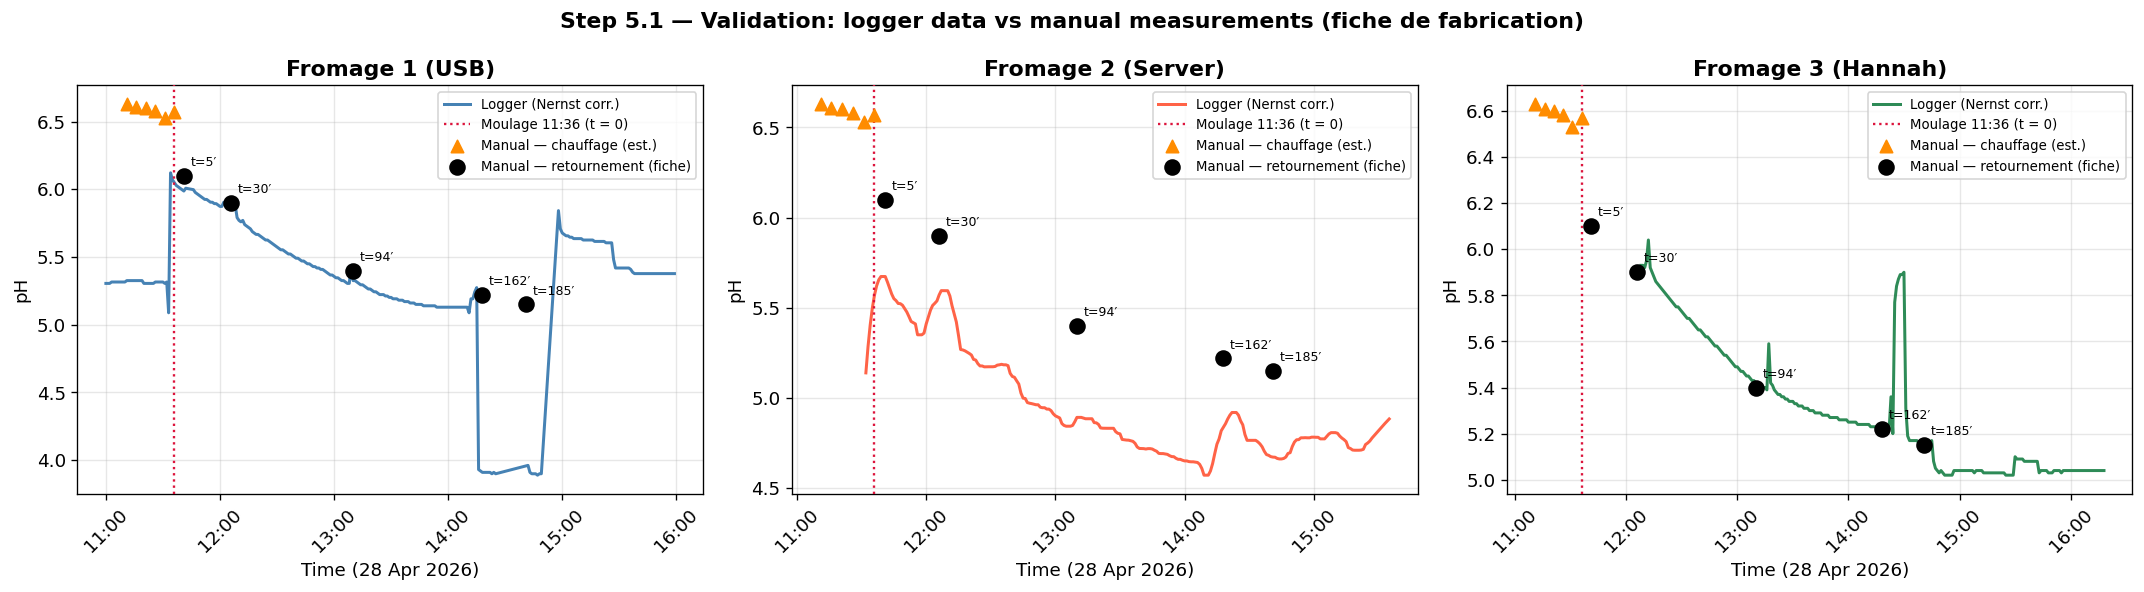

Residuals (logger pH − manual pH) at retournement time points:

       t_min  pH_manual  Δ USB Δ Hannah
Time                                   
11:41      5       6.10 -0.113        —
12:06     30       5.90 -0.037        —
13:10     94       5.40 -0.074     0.02
14:18    162       5.22 -1.310      0.0
14:41    185       5.15 -1.189      0.0

Note: Hannah probe starts at 12:08 → no data for t=5 and t=30 min points.


In [16]:
# ── Overlay manual points on Nernst-corrected curves ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pH2_corr_vis = pH2_corr.rolling(window=5, center=True).median()

specs = [
    (pH1_corr,     'Fromage 1 (USB)',    'steelblue'),
    (pH2_corr_vis, 'Fromage 2 (Server)', 'tomato'),
    (pH3_corr,     'Fromage 3 (Hannah)', 'seagreen'),
]

for ax, (ph, label, color) in zip(axes, specs):
    # Continuous logger curve
    ax.plot(ph.index, ph.values, color=color, linewidth=1.8,
            label='Logger (Nernst corr.)', zorder=2)

    # True t=0 (moulage)
    ax.axvline(T0_MOULAGE, color='crimson', linewidth=1.4, linestyle=':',
               label='Moulage 11:36 (t = 0)', zorder=3)

    # Chauffage manual points
    ax.scatter(manual_chauffage.index, manual_chauffage['pH'],
               color='darkorange', s=55, marker='^', zorder=5,
               label='Manual — chauffage (est.)')

    # Retournement manual points
    ax.scatter(manual_retournement.index, manual_retournement['pH'],
               color='black', s=80, marker='o', zorder=6,
               label='Manual — retournement (fiche)')

    # Annotate retournement points with t_min
    for dt, row in manual_retournement.iterrows():
        ax.annotate(f"t={int(row['t_min'])}′",
                    xy=(dt, row['pH']),
                    xytext=(4, 6), textcoords='offset points',
                    fontsize=7.5, color='black')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('pH')
    ax.set_xlabel('Time (28 Apr 2026)')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Step 5.1 — Validation: logger data vs manual measurements (fiche de fabrication)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05b_validation_manual.png', bbox_inches='tight')
plt.show()

# ── Residuals table — logger vs manual for sensors with overlapping data ──────
print('Residuals (logger pH − manual pH) at retournement time points:\n')
rows_resid = []
for dt, row in manual_retournement.iterrows():
    r = {'Time': dt.strftime('%H:%M'), 't_min': int(row['t_min']),
         'pH_manual': row['pH']}
    for ph_series, sname in [(pH1_corr, 'Δ USB'), (pH3_corr, 'Δ Hannah')]:
        if ph_series.index[0] <= dt <= ph_series.index[-1]:
            idx = ph_series.index.get_indexer([dt], method='nearest')[0]
            r[sname] = round(ph_series.iloc[idx] - row['pH'], 3)
        else:
            r[sname] = '—'
    rows_resid.append(r)

df_resid = pd.DataFrame(rows_resid).set_index('Time')
print(df_resid.to_string())
print('\nNote: Hannah probe starts at 12:08 → no data for t=5 and t=30 min points.')

---
## 6. Modèle de Luedeking-Piret

Le modèle de Luedeking-Piret décrit la vitesse de production d'acide en fonction de la croissance bactérienne :

$$\frac{dA}{dt} = \alpha \frac{dX}{dt} + \beta X \qquad \frac{dX}{dt} = \mu \cdot X(1-X)$$

- **A(t)** = proxy d'acide lactique = pH_init − pH(t)
- **X(t)** = biomasse bactérienne normalisée (logistique)
- **α** = coefficient de production lié à la croissance active (phase exponentielle)
- **β** = coefficient de production indépendant de la croissance (phase stationnaire)

### Problème du point de départ — forme en S artificielle

Lorsque la fenêtre de fit débute **après** le vrai début de fermentation (ici 12:10 alors que les bactéries sont actives depuis ~11:36 voire avant), la biomasse X est déjà à un stade avancé au moment t=0 de la fenêtre. Si on force **X₀ = 0.01** (valeur fixe), l'optimiseur est contraint d'utiliser un **μ irréaliste** (μ >> 2 h⁻¹) pour que X atteigne rapidement la valeur réelle — ce qui crée une **forme en S artificielle** dans A(t) simulé, absente dans les données observées.

Le lait contient deux populations bactériennes :
- **Bactéries mésophiles** (MFR 32°C) : actives à ~32 °C, phase de croissance principale pendant le chauffage
- **Bactéries thermophiles** (MFR 38°C) : plus actives à ~38-40 °C, dominantes pendant et après le moulage

Ces deux populations peuvent agir à des **phases différentes** de l'acidification, rendant le point de départ X₀ difficile à fixer a priori.

**Correction appliquée ici :** X₀ est inclus comme **4ème paramètre libre** dans l'optimisation (borné entre 0 et 1). L'optimiseur détermine la fraction de biomasse initiale cohérente avec le signal A(t) observé :
- X₀ ≈ 0.01 → bactéries viennent d'entrer en croissance (début réel de fermentation)
- X₀ ≈ 0.9  → bactéries déjà en phase stationnaire au début de la fenêtre (fermentation avancée)

In [17]:
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

def lp_ode(t, y, mu, alpha, beta):
    """Système ODE Luedeking-Piret.
    dX/dt = mu * X * (1 - X)      croissance logistique normalisée
    dA/dt = alpha*dXdt + beta*X    production d'acide
    """
    X, A = y
    dXdt = mu * X * (1 - X)
    dAdt = alpha * dXdt + beta * X
    return [dXdt, dAdt]

def fit_lp_ode(ph_series, fit_start, fit_end):
    """Identifie (μ, α, β, X₀) par intégration numérique + minimisation.
    X₀ est un paramètre libre — évite la forme en S artificielle liée
    à une biomasse initiale mal estimée.
    """
    ph = ph_series[(ph_series.index >= fit_start) & (ph_series.index <= fit_end)].dropna()
    ph = ph.rolling(window=5, center=True, min_periods=1).median()
    t     = (ph.index - ph.index[0]).total_seconds() / 3600
    A_obs = np.clip(ph.values[0] - ph.values, 0, None)

    def residuals(params):
        mu, alpha, beta, X0 = params
        if mu <= 0 or alpha < 0 or beta < 0 or not (0 < X0 < 1):
            return 1e10
        sol = solve_ivp(lp_ode, [t[0], t[-1]], [X0, 0.0],
                        args=(mu, alpha, beta),
                        t_eval=t, method='RK45', rtol=1e-6, atol=1e-8)
        if not sol.success or sol.y.shape[1] != len(t):
            return 1e10
        return np.sum((sol.y[1] - A_obs) ** 2)

    # Multi-start sur X₀ pour éviter les minima locaux
    best_res = None
    for x0_init in [0.01, 0.3, 0.7, 0.95]:
        res = minimize(residuals, x0=[2.0, 0.3, 0.1, x0_init], method='Nelder-Mead',
                       options={'xatol': 1e-7, 'fatol': 1e-9, 'maxiter': 12000})
        if best_res is None or res.fun < best_res.fun:
            best_res = res

    mu_f, alpha_f, beta_f, X0_f = best_res.x

    sol = solve_ivp(lp_ode, [t[0], t[-1]], [X0_f, 0.0],
                    args=(mu_f, alpha_f, beta_f),
                    t_eval=t, method='RK45', rtol=1e-6, atol=1e-8)
    A_sim = sol.y[1]; X_sim = sol.y[0]
    ss_res = np.sum((A_sim - A_obs) ** 2)
    ss_tot = np.sum((A_obs - A_obs.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return dict(t=t, A_obs=A_obs, A_sim=A_sim, X_sim=X_sim,
                mu=mu_f, alpha=alpha_f, beta=beta_f, X0=X0_f, r2=r2)

# ── Fenêtre d'acidification active ───────────────────────────────────────────
FW_START_LP = pd.Timestamp('2026-04-28 12:10')
FW_END_LP   = pd.Timestamp('2026-04-28 14:00')

series_lp = [
    ('Fromage 1 (USB)',    pH1_corr,     'steelblue'),
    ('Fromage 2 (Server)', pH2_corr_vis, 'tomato'),
    ('Fromage 3 (Hannah)', pH3_corr,     'seagreen'),
]

results_lp = {}
for name, ph_series, color in series_lp:
    try:
        res = fit_lp_ode(ph_series, FW_START_LP, FW_END_LP)
        res['color'] = color
        results_lp[name] = res
        x0_phase = ('début croissance' if res['X0'] < 0.2
                    else 'croissance active' if res['X0'] < 0.6
                    else 'phase stationnaire')
        print(f"{name}:")
        print(f"  μ={res['mu']:.3f} h⁻¹  α={res['alpha']:.4f}  β={res['beta']:.4f}  X₀={res['X0']:.3f}  R²={res['r2']:.3f}")
        print(f"  X₀ interprétation : {x0_phase}")
    except Exception as e:
        print(f'{name} : erreur — {e}')

# ── Vérification physique ─────────────────────────────────────────────────────
print("\n── Plausibilité physique de μ ───────────────────────────────────────")
print("   (bactéries lactiques typiques : μ = 0.3–2.0 h⁻¹ à 37°C)")
for name, res in results_lp.items():
    flag = '✓' if 0.1 < res['mu'] < 5 else '⚠ irréaliste'
    print(f"  {name}: μ = {res['mu']:.3f} h⁻¹  {flag}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────────
rows_lp = []
for name, res in results_lp.items():
    ratio = round(res['alpha'] / res['beta'], 2) if abs(res['beta']) > 1e-6 else '∞'
    dom   = 'croissance' if res['alpha'] > res['beta'] else 'stationnaire'
    rows_lp.append({
        'Fromage':               name,
        'X₀ (biomasse init.)':   round(res['X0'],    3),
        'μ (taux croissance)':    round(res['mu'],    4),
        'α (growth-assoc.)':      round(res['alpha'], 4),
        'β (non-growth-assoc.)':  round(res['beta'],  4),
        'α/β':                    ratio,
        'Dominance':              dom,
        'R²':                     round(res['r2'],    3),
    })
pd.DataFrame(rows_lp).set_index('Fromage')

Fromage 1 (USB):
  μ=0.967 h⁻¹  α=4.0092  β=0.0000  X₀=0.793  R²=0.998
  X₀ interprétation : phase stationnaire
Fromage 2 (Server):
  μ=6.488 h⁻¹  α=7412.1483  β=0.3099  X₀=1.000  R²=0.971
  X₀ interprétation : phase stationnaire
Fromage 3 (Hannah):
  μ=1.167 h⁻¹  α=3.5393  β=0.0000  X₀=0.767  R²=0.998
  X₀ interprétation : phase stationnaire

── Plausibilité physique de μ ───────────────────────────────────────
   (bactéries lactiques typiques : μ = 0.3–2.0 h⁻¹ à 37°C)
  Fromage 1 (USB): μ = 0.967 h⁻¹  ✓
  Fromage 2 (Server): μ = 6.488 h⁻¹  ⚠ irréaliste
  Fromage 3 (Hannah): μ = 1.167 h⁻¹  ✓


,X₀ (biomasse init.),μ (taux croissance),α (growth-assoc.),β (non-growth-assoc.),α/β,Dominance,R²
Fromage,,,,,,,
Fromage 1 (USB),0.793,0.9669,4.0092,0.0000,∞,croissance,0.998
Fromage 2 (Server),1.000,6.4877,7412.1483,0.3099,23920.88,croissance,0.971
Fromage 3 (Hannah),0.767,1.1674,3.5393,0.0000,∞,croissance,0.998


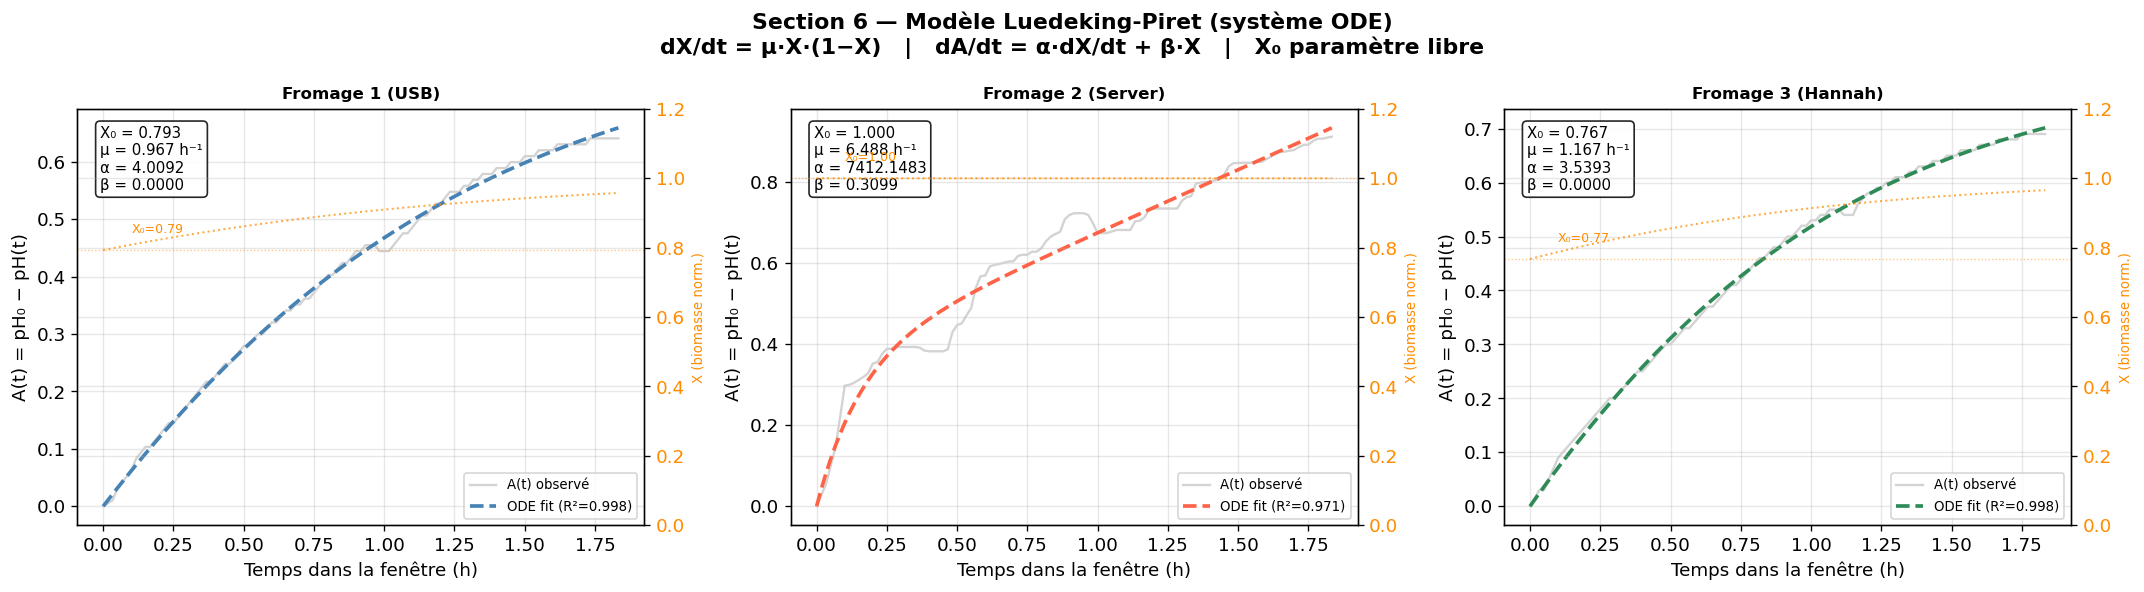

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results_lp.items()):
    color = res['color']

    ax.plot(res['t'], res['A_obs'], color='lightgrey', linewidth=1.4,
            label='A(t) observé')
    ax.plot(res['t'], res['A_sim'], color=color, linewidth=2.2,
            linestyle='--', label=f'ODE fit (R²={res["r2"]:.3f})')

    ax2 = ax.twinx()
    ax2.plot(res['t'], res['X_sim'], color='darkorange', linewidth=1.2,
             linestyle=':', alpha=0.75, label='X(t) simulé')
    ax2.set_ylabel('X (biomasse norm.)', color='darkorange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, 1.2)

    # Marquer X₀ sur la courbe X simulée
    ax2.axhline(res['X0'], color='darkorange', linewidth=0.8, linestyle=':',
                alpha=0.5)
    ax2.annotate(f'X₀={res["X0"]:.2f}',
                 xy=(res['t'][3], res['X0']),
                 xytext=(res['t'][3] + 0.05, res['X0'] + 0.05),
                 fontsize=7.5, color='darkorange')

    ax.text(0.04, 0.96,
            f'X₀ = {res["X0"]:.3f}\nμ = {res["mu"]:.3f} h⁻¹\nα = {res["alpha"]:.4f}\nβ = {res["beta"]:.4f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Temps dans la fenêtre (h)')
    ax.set_ylabel('A(t) = pH₀ − pH(t)')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    'Section 6 — Modèle Luedeking-Piret (système ODE)\n'
    'dX/dt = μ·X·(1−X)   |   dA/dt = α·dX/dt + β·X   |   X₀ paramètre libre',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_luedeking_piret_ode.png', bbox_inches='tight')
plt.show()

---
## 7. Notes & Next Steps

### Validated findings (cross-checked against fiche de fabrication)
- ✅ **Hannah (PHLOT001)** agrees with manual measurements within ±0.03 pH — most reliable logger
- ✅ **USB** agrees well at t=5 and t=30 min; spike at 14:18 (pH 4.02 vs manual 5.22) now removed by rolling-median filter
- ✅ **True t=0 (moulage)** identified: **11:36** — curves now anchored to the real process start
- ⚠️ Hannah probe starts at **12:08** — first 32 min of retournement only covered by USB and manual points

### Known limitations
- [ ] USB calibration temperature not confirmed (assumed **35 °C**); confirm with instrument log
- [ ] Fromage 2 (Server) starts at 10:00 — **1h36 before moulage**; likely measures a different cheese piece or was inserted during fabrication phase
- [ ] Culture ratio differs significantly between sessions (MFR38/MFR32 = 3.45:1 in Apr vs 1:2 in May) → probable driver of yield difference (12.17 % vs 11.8 %)
- [ ] Fresh yield is the only quality metric available; texture, moisture and sensory scores still needed

### To collect in future sessions
- [ ] Insert all probes **before moulage** to capture the full retournement curve from t=0
- [ ] Record clock time of starter addition (true fermentation t=0)
- [ ] Keep pH recording until target pH ≤ 5.0 is reached
- [ ] Record milk mass and composition (fat %, protein %) for each session
- [ ] Add titratable acidity (°Dornic) measurements at key time points
- [ ] Standardise culture ratios across sessions, or document any intentional changes